# **MAIZE CROP YIELD PREDICTION USING MACHINE LEARNING ALGORITHMS**




In [32]:
#IMPORTING PACKAGES
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [7]:
#READING DATASET
df = pd.read_csv("/content/Maizeyeild.csv - Sheet1 (1).csv")
print(df)

      N   P    K  Crop_Yeild_ton_per_hectare
0   132  62   22                       11.42
1   129  99   50                       10.23
2    93  56  100                        8.44
3    38  83  137                       11.00
4    79  26   53                        9.40
5    83  29   53                        9.93
6   135  28   70                        6.42
7    43  82  122                       10.82
8    77  67   30                        8.37
9   165  16   45                       13.21
10   92  81   61                       11.97
11   34  23   50                        9.84
12   66  31  126                       11.08
13   56  42  143                        8.39
14  172  31   49                        7.91


1.SIMPLE LINEAR REGRESSION(USING N ONLY)

In [8]:
#simple Linear Regression
X = df[['N']]     # single independent variable
y = df['Crop_Yeild_ton_per_hectare']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = LinearRegression()
model.fit(X_train, y_train)

print("Intercept:", model.intercept_)
print("Coefficients:", model.coef_)

y_predHD=model.predict([[30.8]])
print(y_predHD)

y_predHD=model.predict(X_test)
print("Predicted:", y_predHD[0:5])
print("Actual:", y_test.values[0:5])

Intercept: 10.130071858538813
Coefficients: [-0.00234916]
[10.05771784]
Predicted: [ 9.82703067 10.04080391  9.99851909]
Actual: [10.23 11.    8.39]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [9]:
# Error calculations
from sklearn import metrics
import numpy as np


print("MAE:", metrics.mean_absolute_error(y_test, y_predHD))
print("MSE:", metrics.mean_squared_error(y_test, y_predHD))
print("RMSE:", np.sqrt(metrics.mean_squared_error(y_test, y_predHD)))
print("R2 Score:", metrics.r2_score(y_test, y_predHD))

MAE: 0.9902281722814544
MSE: 1.223258364796501
RMSE: 1.1060101106212823
R2 Score: -0.02026998342710451


In [10]:
from sklearn.linear_model import LinearRegression
reg=LinearRegression()
#train the model
reg.fit(X_train,y_train)

LinearRegression()

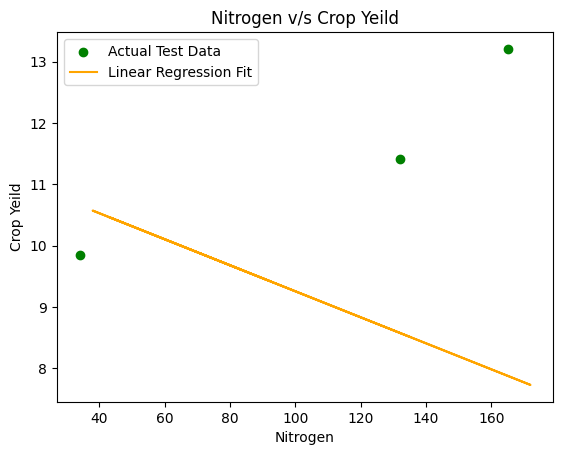

In [11]:
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Define X and y specifically for the simple linear regression plot for 'N'
X_n_plot = df[['N']]
y_n_plot = df['Crop_Yeild_ton_per_hectare']

# Create a train-test split specifically for this plot
X_train_n, X_test_n, y_train_n, y_test_n = train_test_split(X_n_plot, y_n_plot, test_size=0.2, random_state=42)

# Train a new Linear Regression model just for this plot
lr_n_model = LinearRegression()
lr_n_model.fit(X_train_n, y_train_n)

# Plotting
plt.scatter(X_test_n['N'], y_test_n, color='green', label='Actual Test Data')
plt.plot(X_train_n['N'], lr_n_model.predict(X_train_n[['N']]), color='orange', label='Linear Regression Fit')
plt.title("Nitrogen v/s Crop Yeild")
plt.xlabel("Nitrogen")
plt.ylabel('Crop Yeild')
plt.legend()
plt.show()

2. Multiple Linear Regression (N, P, K)

In [12]:
#Multiple Linear Regression
X = df[['N','P','K']]
y = df['Crop_Yeild_ton_per_hectare']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = LinearRegression()
model.fit(X_train, y_train)

print("Intercept:", model.intercept_)
print("Coefficients:", model.coef_)

y_predHD=model.predict([[100,50,50]])
print(y_predHD)

y_predHD=model.predict(X_test)
print("Predicted:", y_predHD[0:5])
print("Actual:", y_test.values[0:5])

# Error calculations
print("MAE:", metrics.mean_absolute_error(y_test, y_predHD))
print("MSE:", metrics.mean_squared_error(y_test, y_predHD))
print("RMSE:", np.sqrt(metrics.mean_squared_error(y_test, y_predHD)))
print("R2 Score:", metrics.r2_score(y_test, y_predHD))

Intercept: 10.62665039215157
Coefficients: [-0.00121226  0.01034789 -0.00941273]
[10.55218235]
Predicted: [10.32724687 10.94423306 10.09384511]
Actual: [9.93 8.37 6.42]
MAE: 2.215108346361085
MSE: 6.760539595709207
RMSE: 2.6001037663349527
R2 Score: -2.278950235575326


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


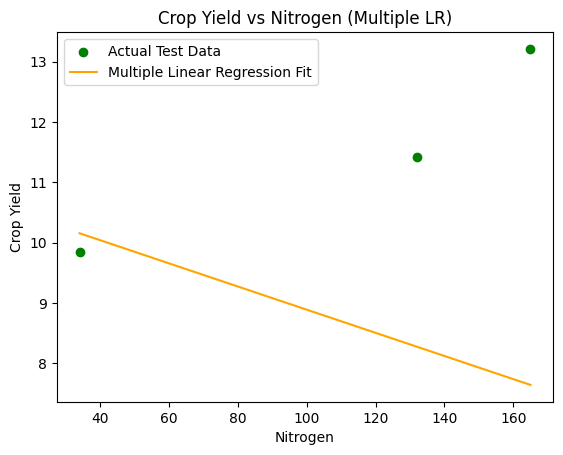

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Multiple Linear Regression setup (PLOT)
X_mlr = df[['N','P','K']]
y_mlr = df['Crop_Yeild_ton_per_hectare']

X_train_mlr, X_test_mlr, y_train_mlr, y_test_mlr = train_test_split(X_mlr, y_mlr, test_size=0.2, random_state=42)

model_mlr = LinearRegression()
model_mlr.fit(X_train_mlr, y_train_mlr)


# Create a range for Nitrogen
X_range_n = np.linspace(X_test_mlr['N'].min(), X_test_mlr['N'].max(), 100)

# Calculate mean of P and K from X_test_mlr to hold them constant
P_mean = X_test_mlr['P'].mean()
K_mean = X_test_mlr['K'].mean()

# Prepare input for prediction, varying N and keeping P and K at their mean
X_line = pd.DataFrame([[n, P_mean, K_mean] for n in X_range_n], columns=['N', 'P', 'K'])

# Plot actual test data for Nitrogen vs Crop Yield
plt.scatter(X_test_mlr['N'], y_test_mlr, color='green', label='Actual Test Data')

# Plot the multiple linear regression fit for Nitrogen
plt.plot(X_range_n, model_mlr.predict(X_line), color='orange', label='Multiple Linear Regression Fit')

plt.title("Crop Yield vs Nitrogen (Multiple LR)")
plt.xlabel("Nitrogen")
plt.ylabel("Crop Yield")
plt.legend()
plt.show()

3. Support Vector Regression (SVR)

In [14]:

from sklearn.svm import SVR
X = df[['N', 'P','K']]
y = df['Crop_Yeild_ton_per_hectare']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = SVR(kernel='rbf')
#model = SVR(kernel='linear')
model.fit(X_train, y_train)

print("Intercept:", model.intercept_)


y_predHD=model.predict(X_test)
print("Predicted:", y_predHD[0:5])
print("Actual:", y_test.values[0:5])

# Error calculations
print("MAE:", metrics.mean_absolute_error(y_test, y_predHD))
print("MSE:", metrics.mean_squared_error(y_test, y_predHD))
print("RMSE:", np.sqrt(metrics.mean_squared_error(y_test, y_predHD)))
print("R2 Score:", metrics.r2_score(y_test, y_predHD))

Intercept: [10.1868068]
Predicted: [9.96467227 9.7058836  9.69202148]
Actual: [9.84 9.4  9.93]
MAE: 0.2228448000160821
MSE: 0.05524724423097055
RMSE: 0.23504732338610143
R2 Score: -0.03030501052369683


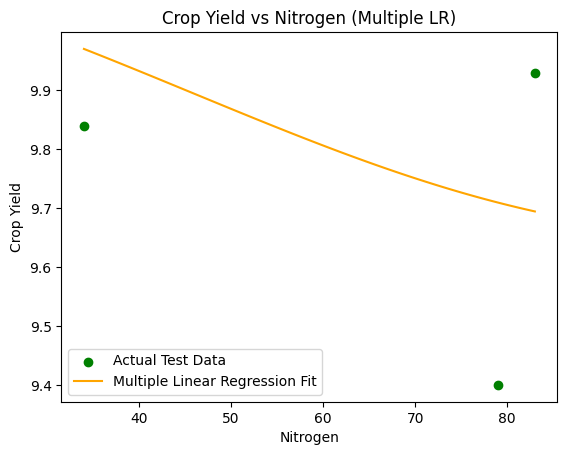

In [15]:
X_range = np.linspace(X_test['N'].min(), X_test['N'].max(), 100)
P_mean = X_test['P'].mean()
K_mean = X_test['K'].mean()

X_line = pd.DataFrame([[n, P_mean, K_mean] for n in X_range], columns=['N', 'P', 'K'])

# Plot
plt.scatter(X_test['N'], y_test, color='green', label='Actual Test Data')
plt.plot(X_range, model.predict(X_line), color='orange', label='Multiple Linear Regression Fit')

plt.title("Crop Yield vs Nitrogen (Multiple LR)")
plt.xlabel("Nitrogen")
plt.ylabel("Crop Yield")
plt.legend()
plt.show()

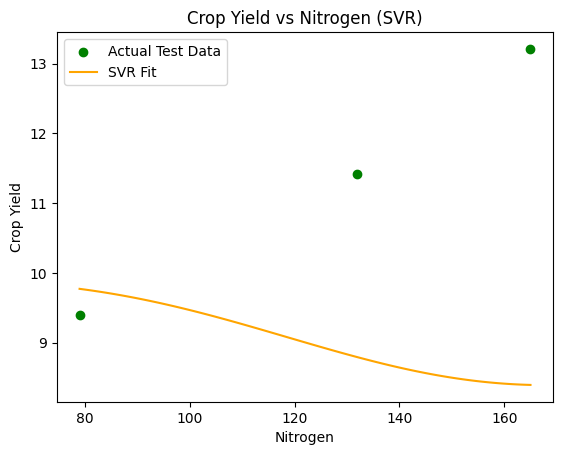

In [17]:
import numpy as np
import matplotlib.pyplot as plt


P_mean = X_test['P'].mean()
K_mean = X_test['K'].mean()


X_range_n = np.linspace(X_test['N'].min(), X_test['N'].max(), 100)


X_line_svr = pd.DataFrame([[n, P_mean, K_mean] for n in X_range_n], columns=['N', 'P', 'K'])

# Plot
plt.scatter(X_test['N'], y_test, color='green', label='Actual Test Data')
plt.plot(X_range_n, model.predict(X_line_svr), color='orange', label='SVR Fit')

plt.title("Crop Yield vs Nitrogen (SVR)")
plt.xlabel("Nitrogen")
plt.ylabel("Crop Yield")
plt.legend()
plt.show()

4.ARTIFICIAL NEURAL NETWORK

In [18]:
#Artificail Neural Network
from sklearn.neural_network import MLPRegressor

X = df[['N', 'P', 'K']]
y = df['Crop_Yeild_ton_per_hectare']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = MLPRegressor(hidden_layer_sizes=(6,6), max_iter=500)

model.fit(X_train, y_train)


y_predHD=model.predict(X_test)
print("Predicted:", y_predHD[0:5])
print("Actual:", y_test.values[0:5])

# Error calculations
print("MAE:", metrics.mean_absolute_error(y_test, y_predHD))
print("MSE:", metrics.mean_squared_error(y_test, y_predHD))
print("RMSE:", np.sqrt(metrics.mean_squared_error(y_test, y_predHD)))
print("R2 Score:", metrics.r2_score(y_test, y_predHD))

Predicted: [10.10994024 12.2813297   9.88627073]
Actual: [11.97 11.    8.39]
MAE: 1.5458867305653239
MSE: 2.4468180725741107
RMSE: 1.56423082458252
R2 Score: -0.07058847867059792


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


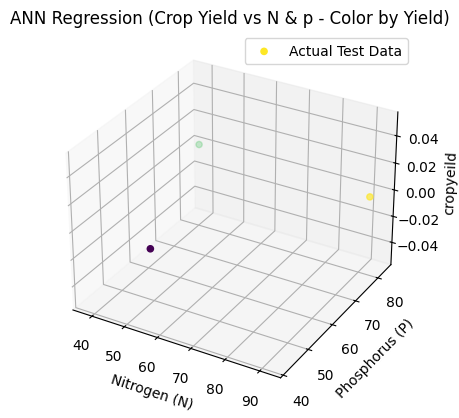

In [19]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')


ax.scatter(X_test['N'], X_test['P'], c=y_test, cmap='viridis', label='Actual Test Data')

ax.set_xlabel('Nitrogen (N)')
ax.set_ylabel('Phosphorus (P)')
ax.set_zlabel('cropyeild')

plt.title("ANN Regression (Crop Yield vs N & p - Color by Yield)")
plt.legend()
plt.show()

5.DECISION TREE REGRESSOR

In [20]:
from sklearn.tree import DecisionTreeRegressor

X = df[['N','P','K']]
y = df['Crop_Yeild_ton_per_hectare']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = DecisionTreeRegressor()
model.fit(X_train, y_train)

DecisionTreeRegressor()

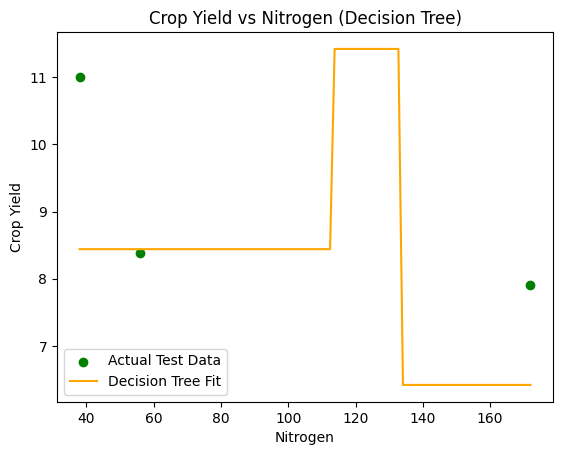

In [21]:
import numpy as np
import matplotlib.pyplot as plt


P_mean = X_test['P'].mean()
K_mean = X_test['K'].mean()


X_range_n = np.linspace(X_test['N'].min(), X_test['N'].max(), 100)


X_plot_dt = pd.DataFrame([[n, P_mean, K_mean] for n in X_range_n], columns=['N', 'P', 'K'])

# Plot
plt.scatter(X_test['N'], y_test, color='green', label='Actual Test Data')
plt.plot(X_range_n, model.predict(X_plot_dt), color='orange', label='Decision Tree Fit')

plt.title("Crop Yield vs Nitrogen (Decision Tree)")
plt.xlabel("Nitrogen")
plt.ylabel("Crop Yield")
plt.legend()
plt.show()

6.VISUALISATION(model comparision)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SVR was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MLPRegressor was fitted with feature names
  warnings.warn(


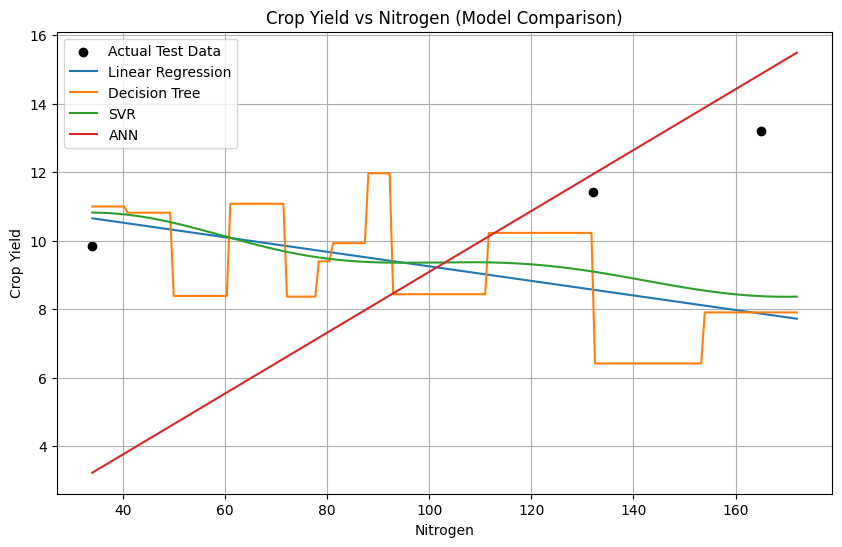

In [33]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

X = df[['N']]
y = df['Crop_Yeild_ton_per_hectare']

# Split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 🔹 Models
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor

lr = LinearRegression()
dt = DecisionTreeRegressor()
svm = SVR(kernel='rbf')
ann = MLPRegressor(hidden_layer_sizes=(6,6), max_iter=500, random_state=42)
# Train
lr.fit(X_train, y_train)
dt.fit(X_train, y_train)
svm.fit(X_train, y_train.values.ravel())
ann.fit(X_train, y_train.values.ravel())

X_grid = np.linspace(X.min().item(), X.max().item(), 200).reshape(-1,1)

# 🔴 Plot
plt.figure(figsize=(10, 6))
plt.scatter(X_test, y_test, color='black', label='Actual Test Data')

plt.plot(X_grid, lr.predict(X_grid), label="Linear Regression")
plt.plot(X_grid, dt.predict(X_grid), label="Decision Tree")
plt.plot(X_grid, svm.predict(X_grid), label="SVR")
plt.plot(X_grid, ann.predict(X_grid), label="ANN")

plt.title("Crop Yield vs Nitrogen (Model Comparison)")
plt.xlabel("Nitrogen")
plt.ylabel("Crop Yield")
plt.legend()
plt.grid(True)
plt.show()

**HYPERPARAMETER TUNING**

In [23]:
from sklearn.model_selection import GridSearchCV

# Common data split used for all tuning experiments
X_all = df[['N', 'P', 'K']]
y_all = df['Crop_Yeild_ton_per_hectare']
X_tr, X_te, y_tr, y_te = train_test_split(X_all, y_all, test_size=0.2, random_state=42)

 SVR — Hyperparameter tuning

In [25]:
 # Grid of hyperparameters to search
svr_param_grid = {
    'kernel':  ['rbf', 'linear', 'poly'],
    'C':       [0.1, 1, 10, 100],
    'epsilon': [0.01, 0.1, 0.5, 1.0],
    'gamma':   ['scale', 'auto']
}

svr_grid = GridSearchCV(
    SVR(),
    svr_param_grid,
    cv=5,                 # 5-fold cross-validation
    scoring='r2',
    n_jobs=-1,            # use all CPU cores
    verbose=1
)
svr_grid.fit(X_tr, y_tr)

print("Best SVR params :", svr_grid.best_params_)
print("Best CV R2 score:", round(svr_grid.best_score_, 4))

best_svr = svr_grid.best_estimator_
y_pred_svr_tuned = best_svr.predict(X_te)

print("\n--- Test-set metrics (tuned SVR) ---")
print("MAE  :", round(metrics.mean_absolute_error(y_te, y_pred_svr_tuned), 4))
print("RMSE :", round(np.sqrt(metrics.mean_squared_error(y_te, y_pred_svr_tuned)), 4))
print("R2   :", round(metrics.r2_score(y_te, y_pred_svr_tuned), 4))

Fitting 5 folds for each of 96 candidates, totalling 480 fits
Best SVR params : {'C': 0.1, 'epsilon': 1.0, 'gamma': 'scale', 'kernel': 'rbf'}
Best CV R2 score: -5.7208

--- Test-set metrics (tuned SVR) ---
MAE  : 2.1763
RMSE : 2.6116
R2   : -2.5987
